### reference
##### Tawara
https://www.kaggle.com/code/ttahara/birdclef-2026-hgnetv2-b0-baseline-inference
##### hengck23
https://www.kaggle.com/code/hengck23/pytorch-differentiable-perchv2

In [1]:
!pip install --no-index \
    -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt \
    --find-links=/kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels

Looking in links: /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/openvino-2026.0.0-20965-cp312-cp312-manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 1))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxscript-0.6.2-py3-none-any.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 2))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxsim-0.6.2-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/requirements.txt (line 3))
Processing /kaggle/input/notebooks/ttahara/birdclef-2026-download-wheels/wheels/onnxruntime-1.24.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from -r /kaggle/input/notebooks/ttahara/birdclef-2

In [2]:
import openvino as ov
print(f"Openvio version {ov.__version__}")

Openvio version 2026.0.0-20965-c6d6a13a886-releases/2026/0


In [3]:
import os
import gc
import sys
import math
import json
import joblib
import random
import numpy as np
import pandas as pd
import typing as tp
from time import time
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

import ast
from pathlib import Path
from itertools import islice
from collections import Counter, defaultdict

import wave
import soundfile

import librosa
import soundfile as sf
from IPython.display import Audio, display

import torch
import torchaudio
from torchvision.transforms import v2 as tvt_v2

from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata
import scipy

# Timm
import timm
print(f"Timm Version {timm.__version__}")

import glob
import warnings
warnings.filterwarnings("ignore")

Timm Version 1.0.25


In [4]:
class CFG():
    SEED            = 42
    N_FOLDS         = 5
    FOLDS_LIST      = [0, 2]
    base_dir        = "/kaggle/input/competitions/birdclef-2026"
    label_dir       = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-5fold-df-and-ss/data"
    timm_model_name = "efficientnet_b0"
    model_path_f1   = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold1-lsehead-b0-model/models"
    model_path_f2   = ""
    model_path_f3   = "/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold3-lsehead-b0-model/models"
    model_path_f4   = ""
    model_path_f5   = ""
    
    # Librosa
    SAMPLING_RATE = 32_000
    N_FFT         = 2_048
    HOP_LEN       = 512
    N_MELS        = 128
    FMIN          = 20
    FMAX          = 16_000
    DURATION      = 5
    # Targets
    NUM_CLASS     = 234
    # normarize
    MEL_NORM      = "MinMax"
    # segments & context
    SEGMENT_SEC   = 5
    CONTEXT_SEC   = 20
    # Mel
    TOP_DB        = 80
    # TTA
    TTA_SHIFTS    = [-2, -1, 0, 1, 2]
    #TTA_SHIFTS    = [-0.5, 0, 0.5]
    
    # Debug
    debug         = False
        
cfg = CFG()
print(f"fram : {(cfg.SAMPLING_RATE*cfg.CONTEXT_SEC)/cfg.HOP_LEN}")

#128 周波数方向（mel bins）
#626 時間方向（time frames）

fram : 1250.0


### Make Directry

In [5]:
MODEL_DIR = "/kaggle/working/onnx"
os.makedirs(MODEL_DIR, exist_ok=True)

### SeedEverything

In [6]:
def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    
seed_everything(cfg.SEED)

### DATA

In [7]:
def load_labels(path):
    with open(path, mode="r") as f:
        labels_dict = json.load(f)
    return {int(k):v for k, v in labels_dict.items()}

### Lavel

In [8]:
idx2label = load_labels(os.path.join(cfg.label_dir, "idx2label.json"))
label2idx = {v:k for k, v in idx2label.items()}

In [9]:
sample_submission = pd.read_csv(os.path.join(cfg.base_dir, "sample_submission.csv"))
sample_submission.head()

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [10]:
sample_submission.columns[1:].tolist() == list(label2idx.keys())

True

In [11]:
species_list = list(label2idx.keys())

def build_5sec_labels(df, species_list, label2idx):
    num_classes = len(species_list)
    rows = []

    for _, row in df.iterrows():
        fname = row["filename"]
        labels = row["labels"]

        start = row["start"]
        end   = row["end"]

        # 5秒単位に展開
        for t in range(5, 61, 5):
            seg_start = t - 5
            seg_end   = t

            # overlap判定
            if not (end <= seg_start or start >= seg_end):
                row_id = f"{fname.replace('.ogg','')}_{t}"

                label_vec = np.zeros(num_classes, dtype=np.float32)

                for l in labels:
                    idx = label2idx.get(l, None)
                    if idx is not None:
                        label_vec[idx] = 1.0

                rows.append([row_id, label_vec])

    # DataFrame化
    out = {}
    for row_id, label_vec in rows:
        if row_id not in out:
            out[row_id] = label_vec
        else:
            out[row_id] = np.maximum(out[row_id], label_vec)

    row_ids = list(out.keys())
    labels  = np.stack(list(out.values()))

    label_df = pd.DataFrame(labels, columns=species_list)
    label_df.insert(0, "row_id", row_ids)

    return label_df

In [12]:
def get_dummy_df():

    train_ss_df = pd.read_csv(
        os.path.join(cfg.base_dir, "train_soundscapes_labels.csv")
    )
    train_ss_df = train_ss_df.drop_duplicates().reset_index(drop=True)

    train_ss_df["labels"] = train_ss_df["primary_label"].str.split(";")

    FORMAT = "%H:%M:%S"
    train_ss_df["start"] = pd.to_datetime(train_ss_df["start"], format=FORMAT, errors="coerce")
    train_ss_df["end"]   = pd.to_datetime(train_ss_df["end"],   format=FORMAT, errors="coerce")

    train_ss_df["start"] = train_ss_df["start"].dt.minute * 60 + train_ss_df["start"].dt.second
    train_ss_df["end"]   = train_ss_df["end"].dt.minute   * 60 + train_ss_df["end"].dt.second

    # =========================
    # select 12segmentation
    # =========================
    # counts      = train_ss_df.groupby("filename").size()
    # valid_files = counts[counts == 12].index

    # train_ss_df = train_ss_df[train_ss_df["filename"].isin(valid_files)].reset_index(drop=True)

    # =========================
    # Sample （50 audio） debug: 5 audio
    # =========================
    if cfg.debug:
        num_audio = 10
    else:
        num_audio = 50
    unique_filename = train_ss_df["filename"].unique()
    selected_ids    = unique_filename[:num_audio]

    train_ss_df = train_ss_df[train_ss_df["filename"].isin(selected_ids)].reset_index(drop=True)

    # =========================
    # row_id 作成（高速版）
    # =========================
    train_ss_df["row_id"] = (
        train_ss_df["filename"].str.replace(".ogg", "", regex=False)
        + "_"
        + train_ss_df["end"].astype(int).astype(str)
    )

    return train_ss_df[["row_id", "labels", "filename", "start", "end"]]


In [13]:
def get_paths(df, file_type="test_soundscapes"):
    paths = []
    added = set()
    for row_id in df["row_id"].values:
        file_id = "_".join(row_id.split("_")[:-1])
        if file_id in added:
            continue
        added.add(file_id)
        paths.append(os.path.join(cfg.base_dir, file_type, f"{file_id}.ogg"))
    return paths

In [14]:
IS_TEST_ENV = len(sample_submission) > 10
print(f"Teat environment is {IS_TEST_ENV}")
file_type = "test_soundscapes" if IS_TEST_ENV else "train_soundscapes"
print(f"file type is {file_type}")
if IS_TEST_ENV:
    ss_paths = get_paths(sample_submission)
else:
    df  = get_dummy_df()
    # ① row_id base （12）
    all_row_ids = []
    for fname in df["filename"].unique():
        stem = fname.replace(".ogg", "")
        for t in range(5, 61, 5):
            all_row_ids.append(f"{stem}_{t}")
    df_all = pd.DataFrame({"row_id": all_row_ids})
    # ② Make GT
    gt_df = build_5sec_labels(df, species_list, label2idx)
    # ③ merge
    oof_gt = df_all.merge(gt_df, on="row_id", how="left").fillna(0)
    # Paths
    ss_paths = get_paths(oof_gt, file_type)
    print(f"Data Shape      : {oof_gt.shape}")
    
print(f"SS Paths Length : {len(ss_paths)}")

Teat environment is False
file type is train_soundscapes
Data Shape      : (600, 235)
SS Paths Length : 50


### Model

In [15]:
class LSEHead(nn.Module):
    def __init__(self, 
                 num_features, 
                 num_classes, 
                 dropout=0.2, 
                 tau=1.0
                ):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(tau))

        self.cls_fc = nn.Sequential(
            nn.Linear(num_features, num_features),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, h):
        # h: (B, C, Freq, Time)

        h = torch.mean(h, dim=2)     # (B, C, Time)
        h = h.transpose(1, 2)        # (B, Time, C)

        timewise_logits = self.cls_fc(h)  # (B, Time, C)
        
        logits = torch.logsumexp(timewise_logits / self.tau, dim=1) * self.tau
        logits = logits - math.log(timewise_logits.size(1))
        return logits

In [16]:
class perchCnnModel(nn.Module):
    def __init__(self, 
                 cfg=cfg, 
                 model_name=cfg.timm_model_name,
                 num_classes=cfg.NUM_CLASS,
                 timm_pretrained=False,
                 head_dropout=0.0, 
                 lse_temperature=0.5,
                ):
        
        super().__init__()
        """
        model    : efficientnet_b0
        num_class: 234
        """
        self.cfg   = cfg
        # Timm
        self.timm_backbone = timm.create_model(model_name, 
                                               pretrained=timm_pretrained, 
                                               in_chans=1,
                                               global_pool="", 
                                               num_classes=0
                                              )

        in_features  = self.timm_backbone.num_features #1280
        out_features = 1536

        self.head = LSEHead(in_features, num_classes, head_dropout, lse_temperature)
        self._init_weights()

    def _init_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.01)
                nn.init.constant_(m.bias, 0.0)
        

    def stable_logsumexp(self, x, dim, tau):
        x = x / tau
        m = x.max(dim=dim, keepdim=True)[0]
        return (m + torch.log(torch.exp(x - m).sum(dim=dim, keepdim=True))).squeeze(dim) * tau

    def forward(self, x):
        B, N, C, freq, T = x.shape
        x = x.view(B*N, C, freq, T)
        
        feat = self.timm_backbone(x)  # (B*N, C, F', T')
    
        _, C, freq, T = feat.shape
        
        feat = feat.view(B, N, C, freq, T)


        # 時間方向pool（freq）
        feat_time = torch.mean(feat, dim=3)  # (B, N, C, T)

        # reshape
        feat_time = feat_time.view(B*N, C, T).transpose(1, 2)
        
        # LSM head
        time_logits = self.head.cls_fc(feat_time) # (B*N, T, num_classes)

        # reshape
        time_logits = time_logits.view(B, N, T, -1)

        # Time LSE 
        chunk_logits = self.stable_logsumexp(time_logits, dim=2, tau=self.head.tau)
        
        return chunk_logits

### convert

In [17]:
N = int(cfg.CONTEXT_SEC/cfg.SEGMENT_SEC)
print(f"N  : {N}")

N  : 4


In [18]:
def convert_torch_to_onnx_to_ov(cfg, model_path, out_dir, N=N):

    os.makedirs(out_dir, exist_ok=True)

    model = perchCnnModel()
    state = torch.load(model_path, map_location="cpu")
    state_dict = state["model"]

    # missing, unexpected = model.load_state_dict(state_dict, strict=False)
    # print(f"missing   : {len(missing)}")
    # print(f"unexpected: {len(unexpected)}")
    model.load_state_dict(state_dict, strict=False)
    model.eval()

    dummy_mels = torch.randn(1, N, 1, 128, 313, dtype=torch.float32)

    base_name = os.path.basename(model_path).split('.')[0]
    onnx_path = os.path.join(out_dir, f"{base_name}.onnx")

    torch.onnx.export(
        model,
        dummy_mels,
        onnx_path,
        opset_version=13,
        do_constant_folding=True,
        input_names=["mels"],
        output_names=["output"],
        dynamic_axes={
            "mels"  : {0: "batch_size"},
            "output": {0: "batch_size"}
        }
    )

    # ===== ONNX → OpenVINO =====
    ov_model = ov.convert_model(onnx_path)

    xml_path = os.path.join(out_dir, f"{base_name}.xml")
    ov.save_model(ov_model, xml_path)

    # ✔ Check
    bin_path = xml_path.replace(".xml", ".bin")
    assert os.path.exists(xml_path), f"{xml_path} not found"
    assert os.path.exists(bin_path), f"{bin_path} not found"

    # ✔ Remove ONNX
    os.remove(onnx_path)

    return xml_path

In [19]:
def get_model_paths(base_paths):
    model_list = []
    for f in cfg.FOLDS_LIST:
        path = base_paths[f]
        model_fold = f"{cfg.timm_model_name}-fold{f+1}.pth"
        model_list.append(os.path.join(path, model_fold))
    return model_list

In [20]:
model_paths = [
    cfg.model_path_f1,
    cfg.model_path_f2,
    cfg.model_path_f3,
    cfg.model_path_f4,
    cfg.model_path_f5,
]
#assert len(model_paths)==len(cfg.FOLDS_LIST)

model_paths_list = get_model_paths(model_paths)
print(f"Model Number : {len(model_paths_list)}")

Model Number : 2


In [21]:
model_paths_list

['/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold1-lsehead-b0-model/models/efficientnet_b0-fold1.pth',
 '/kaggle/input/datasets/tatsuyayamamoto/bird-2026-pseudo2-fold3-lsehead-b0-model/models/efficientnet_b0-fold3.pth']

### Compiled

In [22]:
xml_paths = []
for model_path in model_paths_list:
    xml_path = convert_torch_to_onnx_to_ov(cfg, model_path, MODEL_DIR)
    xml_paths.append(xml_path)

ov_model_list = []
for xml_path in xml_paths:
    compiled_model = ov.compile_model(
        xml_path,
        "CPU",
        {
            "PERFORMANCE_HINT"     : "THROUGHPUT",
            "INFERENCE_NUM_THREADS": 4,
            "NUM_STREAMS"          : "AUTO",
        }
    )
    ov_model_list.append(compiled_model)
    print("Successfully!!")
print("Done")

W0531 00:34:06.987000 16 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0531 00:34:07.887000 16 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0531 00:34:07.888000 16 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, ali

[torch.onnx] Obtain model graph for `perchCnnModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `perchCnnModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Translate the graph into ONNX... ✅
Applied 100 of general pattern rewrite rules.


W0531 00:34:18.285000 16 torch/export/pt2_archive/_package.py:1086] Unable to load package. f must be a buffer or a file ending in .pt2. Instead got {/kaggle/working/onnx/efficientnet_b0-fold1.onnx}
W0531 00:34:18.298000 16 torch/export/__init__.py:454] Ran into the following error when deserializing
W0531 00:34:18.298000 16 torch/export/__init__.py:454] Traceback (most recent call last):
W0531 00:34:18.298000 16 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/__init__.py", line 449, in load
W0531 00:34:18.298000 16 torch/export/__init__.py:454]     pt2_contents = load_pt2(
W0531 00:34:18.298000 16 torch/export/__init__.py:454]                    ^^^^^^^^^
W0531 00:34:18.298000 16 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_archive/_package.py", line 1098, in load_pt2
W0531 00:34:18.298000 16 torch/export/__init__.py:454]     with PT2ArchiveReader(f) as archive_reader:
W0531 00:34:18.298000 16

[torch.onnx] Obtain model graph for `perchCnnModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `perchCnnModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Translate the graph into ONNX... ✅
Applied 100 of general pattern rewrite rules.


W0531 00:34:29.978000 16 torch/export/pt2_archive/_package.py:1086] Unable to load package. f must be a buffer or a file ending in .pt2. Instead got {/kaggle/working/onnx/efficientnet_b0-fold3.onnx}
W0531 00:34:29.983000 16 torch/export/__init__.py:454] Ran into the following error when deserializing
W0531 00:34:29.983000 16 torch/export/__init__.py:454] Traceback (most recent call last):
W0531 00:34:29.983000 16 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/__init__.py", line 449, in load
W0531 00:34:29.983000 16 torch/export/__init__.py:454]     pt2_contents = load_pt2(
W0531 00:34:29.983000 16 torch/export/__init__.py:454]                    ^^^^^^^^^
W0531 00:34:29.983000 16 torch/export/__init__.py:454]   File "/usr/local/lib/python3.12/dist-packages/torch/export/pt2_archive/_package.py", line 1098, in load_pt2
W0531 00:34:29.983000 16 torch/export/__init__.py:454]     with PT2ArchiveReader(f) as archive_reader:
W0531 00:34:29.983000 16

Successfully!!
Successfully!!
Done


### Preprocessing

In [23]:
class BirdPreprocess:
    def __init__(self, cfg):
        self.cfg = cfg

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=cfg.SAMPLING_RATE,
            n_fft=cfg.N_FFT,
            hop_length=cfg.HOP_LEN,
            n_mels=cfg.N_MELS,
            f_min=cfg.FMIN,
            f_max=cfg.FMAX,
            power=2.0, 
            center=True,
            norm="slaney",
            mel_scale="slaney"
        )
        """
        center=True,
        norm="slaney",
        mel_scale="slaney"
        
        """
        
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=cfg.TOP_DB)

    def split_audio_batch(self, waves, hop_sec):
        sr      = self.cfg.SAMPLING_RATE
        seg_sec = self.cfg.SEGMENT_SEC

        B, T = waves.shape
        chunk = int(sr * seg_sec)
        hop   = int(sr * hop_sec)

        chunks = []
        for start in range(0, T, hop):
            end = start + chunk
            if end > T:
                pad = end - T
                chunk_wave = np.pad(waves[:, start:T], ((0,0),(0,pad)))
            else:
                chunk_wave = waves[:, start:end]
            chunks.append(chunk_wave)

        return np.stack(chunks, axis=1)  # (B, N, L)

    def waves_to_mels_batch_fast(self, waves):
        B, N, L = waves.shape

        waves = waves.reshape(B * N, L)

        waves = torch.from_numpy(waves).float()

        mel = self.mel_transform(waves)
        mel = self.amplitude_to_db(mel)

        mel = (mel + self.cfg.TOP_DB) / self.cfg.TOP_DB
        mel = torch.clamp(mel, 1e-6, 1.0)
        mel = mel ** 0.7

        mel = mel.unsqueeze(1)

        mel = mel.view(B, N, 1, self.cfg.N_MELS, -1)

        return mel.numpy()

    def __call__(self, wave):
        # wave: (T,) → (1, T)
        #wave = wave[None, :]

        x   = self.split_audio_batch(wave[None, :], hop_sec=self.cfg.SEGMENT_SEC)
        mel = self.waves_to_mels_batch_fast(x)

        return mel[0]  # (N, 1, F, T)

### Pipeline

In [24]:
if cfg.debug:
    preprocess   = BirdPreprocess(cfg)
    
    sample_path  = ss_paths[0]
    base_wave, _ = sf.read(sample_path, dtype=np.float32)
    
    target_len = cfg.SAMPLING_RATE * 60  # 60 sec
    
    # =========================================================
    # fix length to 60 sec
    # =========================================================
    if len(base_wave) < target_len:
        base_wave = np.pad(base_wave, (0, target_len - len(base_wave)))
    else:
        base_wave = base_wave[:target_len]
    
    # =========================================================
    # params
    # =========================================================
    sr           = cfg.SAMPLING_RATE
    segment_sec  = cfg.SEGMENT_SEC      # 5
    context_sec  = cfg.CONTEXT_SEC      # 20
    
    segment_len  = sr * segment_sec
    num_chunks   = context_sec // segment_sec   # 4
    
    waves_list = []
    for target_start_sec in range(0, 60, context_sec):
    
        chunk_list = []
        for offset_sec in range(num_chunks):
    
            chunk_start_sec = target_start_sec + offset_sec * segment_sec
            chunk_end_sec   = chunk_start_sec + segment_sec
    
            start = chunk_start_sec * sr
            end   = chunk_end_sec   * sr
    
            if end > target_len:
                
                chunk     = np.zeros(segment_len, dtype=np.float32)
                valid_len = max(0, target_len - start)
            
                if valid_len > 0:
                    # valid region
                    chunk[:valid_len] = base_wave[start:target_len]
            
                    # remain region
                    remain     = segment_len - valid_len
                    repeat_src = chunk[:valid_len]
            
                    # repeat enough
                    repeat_pad = np.tile(
                        repeat_src,
                        int(np.ceil(remain / valid_len))
                    )[:remain]
            
                    chunk[valid_len:] = repeat_pad
            else:
                chunk = base_wave[start:end]
            
            chunk_list.append(chunk.astype(np.float32))
    
        chunk_list = np.stack(chunk_list)   # (4, samples)
        waves_list.append(chunk_list)
    
    waves = np.stack(waves_list)            # (3, 4, samples)
    # Normalize
    rms = np.sqrt(np.mean(waves**2, axis=-1, keepdims=True))
    waves = waves * (0.1 / (rms + 1e-6))
    # Mel
    mels  = preprocess.waves_to_mels_batch_fast(waves)
    print(f"Waves: {waves.shape}")
    print(f"Mels : {mels.shape}")
    
    for b in range(3):
        fig, axes = plt.subplots(1, 4, figsize=(16, 3))
        for i in range(4):
            s_mel = mels[b, i, 0]
            axes[i].imshow(s_mel, aspect='auto', origin='lower')
            axes[i].set_title(f"chunk {i}", size=16)
        plt.tight_layout()
        plt.show()

In [25]:
def np_sigmoid(x):
    return 1 / (1 + np.exp(-x))
    
if cfg.debug:
    for ov_model in ov_model_list:
        input_name = ov_model.inputs[0].get_any_name()
        break
    torch_input = torch.tensor(mels)
    onnx_input  = mels.copy()
    # torch
    model = perchCnnModel()
    state = torch.load(model_path, map_location="cpu")
    state_dict = state["model"]
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    torch.set_grad_enabled(False)
    with torch.no_grad():
        torch_logits = model(torch_input).cpu().numpy()
    
    # onnx output
    onnx_logits = ov_model({input_name: onnx_input})[0]
    
    print("torch:", torch_logits.max(), torch_logits.mean())
    print("onnx :", onnx_logits.max(), onnx_logits.mean())
    print(torch_logits.shape, onnx_logits.shape)
    # sigmoid
    preds = np_sigmoid(onnx_logits)
    # Reshape
    preds = preds.reshape(12, 234)
    
    print("preds :", preds.shape)
    
    sample_row = df[df["filename"] ==sample_path.split("/")[-1]]
    for i in range(12):
        row = sample_row.iloc[i]
        row_labels = row["labels"]
        start, end = row["start"], row["end"]
        print(f"preds max : {preds[i].max():.6f}")
        print(f"preds min : {preds[i].min():.6f}")
        print(f"preds mean: {preds[i].mean():.6f}")
        pred_5 = np.argsort(preds[i])[-5:]
        pred_labels = [idx2label[i] for i in pred_5]
        print(f"{start}-{end}")
        print(f"GT   : {row_labels}")
        print(f"Pred : {pred_labels}")
        print(f"True : {np.sum((np.isin(row_labels, pred_labels))).item()}")
        print({j.item():preds[i][j].item() for j in pred_5})
        print()

In [26]:
if cfg.debug:
    preprocess   = BirdPreprocess(cfg)
    
    sample_path  = ss_paths[0]
    base_wave, _ = sf.read(sample_path, dtype=np.float32)
    
    target_len = cfg.SAMPLING_RATE * 60  # 60 sec
    
    # =========================================================
    # fix length to 60 sec
    # =========================================================
    if len(base_wave) < target_len:
        base_wave = np.pad(base_wave, (0, target_len - len(base_wave)))
    else:
        base_wave = base_wave[:target_len]

    # =========================================================
    # params
    # =========================================================
    sr           = cfg.SAMPLING_RATE
    segment_sec  = cfg.SEGMENT_SEC      # 5
    context_sec  = cfg.CONTEXT_SEC      # 20
    
    segment_len  = sr * segment_sec
    num_chunks   = context_sec // segment_sec   # 4
    
    
    waves_list = []
    for target_start_sec in range(0, 60, context_sec):
        tta_chunk_list = []
        for tta_shift in cfg.TTA_SHIFTS:
            chunk_list = []
            for offset_sec in range(num_chunks):
        
                chunk_start_sec = target_start_sec + offset_sec * segment_sec + tta_shift
                chunk_end_sec   = chunk_start_sec + segment_sec
        
                start = int(chunk_start_sec * sr)
                end   = int(chunk_end_sec   * sr)
        
                if start < 0:
                    chunk = np.zeros(segment_len, dtype=np.float32)
                    valid_end = min(end, target_len)
                
                    if valid_end > 0:
                        valid = base_wave[:valid_end]
                        insert_start = -start
                
                        chunk[insert_start:insert_start + len(valid)] = valid
                
                elif end > target_len:
                    chunk = np.zeros(segment_len, dtype=np.float32)
                    valid_len = max(0, target_len - start)
                
                    if valid_len > 0:
                
                        chunk[:valid_len] = base_wave[start:target_len]
                        remain = segment_len - valid_len
                
                        repeat_src = chunk[:valid_len]
                
                        repeat_pad = np.tile(
                            repeat_src,
                            int(np.ceil(remain / valid_len))
                        )[:remain]
                
                        chunk[valid_len:] = repeat_pad
                
                else:
                    chunk = base_wave[start:end]
    
                chunk = chunk[:segment_len]
                chunk_list.append(chunk.astype(np.float32))
                
            chunk_list = np.stack(chunk_list)   # (4,samples)
            tta_chunk_list.append(chunk_list)
    
        # (3tta, 4, samples)
        tta_chunk_list = np.stack(tta_chunk_list)
        waves_list.append(tta_chunk_list)
        
    waves = np.stack(waves_list)
    # (3,3,4,samples)
    
    # reshape
    waves = waves.reshape(9, 4, -1)
    
    # Normalize
    rms = np.sqrt(np.mean(waves**2, axis=-1, keepdims=True))
    waves = waves * (0.1 / (rms + 1e-6))
    
    # Mel
    mels = preprocess.waves_to_mels_batch_fast(waves)
    print(f"Waves: {waves.shape}")
    print(f"Mels : {mels.shape}")
    
    debug_mels = mels.reshape(3, 3, 4, 1, 128, 313)
    tta_names = cfg.TTA_SHIFTS
    for b in range(3):
        for tta_idx, tta_shift in enumerate(tta_names):
            fig, axes = plt.subplots(1, 4, figsize=(16, 3))
            for i in range(4):
                s_mel = debug_mels[b, tta_idx, i, 0]
                axes[i].imshow(s_mel,aspect='auto',origin='lower')

                axes[i].set_title(
                    f"TTA {tta_shift} | chunk {i}",
                    size=14
                )

            plt.tight_layout()
            plt.show()

In [27]:
if cfg.debug:
    torch_input = torch.tensor(mels)
    onnx_input  = mels.copy()
    # torch
    model = perchCnnModel()
    state = torch.load(model_path, map_location="cpu")
    state_dict = state["model"]
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    torch.set_grad_enabled(False)
    with torch.no_grad():
        torch_logits = model(torch_input).cpu().numpy()
    
    # onnx output
    onnx_logits = ov_model({input_name: onnx_input})[0]
    
    print("torch:", torch_logits.max(), torch_logits.mean())
    print("onnx :", onnx_logits.max(), onnx_logits.mean())
    print(torch_logits.shape, onnx_logits.shape)
    # sigmoid
    preds = np_sigmoid(onnx_logits)
    # Reshape
    debug_preds = preds.reshape(3, 3, 4, 234)
    
    print("preds :", debug_preds.shape)
    
    tta_names = [-1, 0, 1]

    sample_row = df[df["filename"] == sample_path.split("/")[-1]]
    
    for b in range(3):
    
        print("=" * 60)
        print(f"WINDOW {b}")
        print("=" * 60)
    
        for tta_idx, tta_shift in enumerate(tta_names):
            print(f"\n--- TTA SHIFT {tta_shift} ---")
    
            for chunk_idx in range(4):
    
                row_idx = b * 4 + chunk_idx
    
                row = sample_row.iloc[row_idx]
    
                row_labels = row["labels"]
    
                start = row["start"]
                end   = row["end"]
    
                p = debug_preds[b, tta_idx, chunk_idx]
    
                print(f"\n{start}-{end}")
    
                print(f"pred max : {p.max():.6f}")
                print(f"pred mean: {p.mean():.6f}")
    
                pred_5 = np.argsort(p)[-5:][::-1]
    
                pred_labels = [
                    idx2label[i]
                    for i in pred_5
                ]
    
                print(f"GT   : {row_labels}")
                print(f"Pred : {pred_labels}")
    
                print(
                    f"True : "
                    f"{np.sum(np.isin(row_labels, pred_labels)).item()}"
                )
    
                print({
                    j.item(): p[j].item()
                    for j in pred_5
                })

In [28]:
# def np_sigmoid(x):
#     return 1 / (1 + np.exp(-x))

def np_sigmoid(x):
    return np.where(
        x >= 0,
        1.0 / (1.0 + np.exp(-np.clip(x, -50, 50))),
        np.exp(np.clip(x, -50, 50)) /
        (1.0 + np.exp(np.clip(x, -50, 50))),
    ).astype(np.float32)

### smoothing & temperature scaling

In [29]:
from scipy.ndimage import convolve1d

In [30]:
#GAUSSIAN_KERNEL = np.array([0.2, 0.6, 0.2], dtype=np.float32)
# y_t=0.2x_{t-1} +0.6x_t+0.2x_{t+1}

#GAUSSIAN_KERNEL = np.array([0.15, 0.7, 0.15], dtype=np.float32)
GAUSSIAN_KERNEL = np.array([0.25, 0.5, 0.25], dtype=np.float32)

def gauss_smooth_final(scores, axis=0, weights=GAUSSIAN_KERNEL):
    smoothed = scores.copy()
    smoothed = convolve1d(
        smoothed,
        weights,
        axis=axis,
        mode='nearest'
    )
    return smoothed

In [31]:
def predict_audio_pipeline(paths, 
                           ov_models, 
                           preprocess, 
                           cfg=cfg, 
                           label2idx=label2idx,
                          ):
    species_list= list(label2idx.keys())
    all_preds   = []
    all_row_ids = []

    for path in tqdm(paths, total=len(paths), desc="infer"):
        # Load audio
        base_wave, _ = sf.read(path, dtype="float32")

        if base_wave.ndim == 2:
            base_wave = base_wave.mean(axis=1)

        target_len = cfg.SAMPLING_RATE * 60  # 60 sec

        # =========================================================
        # fix length to 60 sec
        # =========================================================
        if len(base_wave) < target_len:
            base_wave = np.pad(base_wave, (0, target_len - len(base_wave)))
        else:
            base_wave = base_wave[:target_len]
        
        # =========================================================
        # params
        # =========================================================
        sr           = cfg.SAMPLING_RATE
        segment_sec  = cfg.SEGMENT_SEC      # 5
        context_sec  = cfg.CONTEXT_SEC      # 20
        
        segment_len  = sr * segment_sec
        num_chunks   = context_sec // segment_sec   # 4
        
        tta_shifts = cfg.TTA_SHIFTS
        num_tta    = len(tta_shifts)
        num_windows= 60 // context_sec
        
        waves_list = []
        for target_start_sec in range(0, 60, context_sec):
            tta_chunk_list = []
            for tta_shift in tta_shifts:
                chunk_list = []
                for offset_sec in range(num_chunks):
            
                    chunk_start_sec = target_start_sec + offset_sec * segment_sec + tta_shift
                    chunk_end_sec   = chunk_start_sec + segment_sec
            
                    start = int(chunk_start_sec * sr)
                    end   = int(chunk_end_sec   * sr)
            
                    if start < 0:
                        chunk = np.zeros(segment_len, dtype=np.float32)
                        valid_end = min(end, target_len)
                    
                        if valid_end > 0:
                            valid = base_wave[:valid_end]
                            insert_start = -start
                    
                            chunk[insert_start:insert_start + len(valid)] = valid
                    
                    elif end > target_len:
                        chunk = np.zeros(segment_len, dtype=np.float32)
                        valid_len = max(0, target_len - start)
                    
                        if valid_len > 0:
                    
                            chunk[:valid_len] = base_wave[start:target_len]
                            remain = segment_len - valid_len
                    
                            repeat_src = chunk[:valid_len]
                    
                            repeat_pad = np.tile(
                                repeat_src,
                                int(np.ceil(remain / valid_len))
                            )[:remain]
                    
                            chunk[valid_len:] = repeat_pad
                    
                    else:
                        chunk = base_wave[start:end]

                    chunk = chunk[:segment_len]
                    chunk_list.append(chunk.astype(np.float32))
                    
                chunk_list = np.stack(chunk_list)   # (4,samples)
                tta_chunk_list.append(chunk_list)
        
            # (3tta, 4, samples)
            tta_chunk_list = np.stack(tta_chunk_list)
            waves_list.append(tta_chunk_list)
            
        waves = np.stack(waves_list)
        # (3,num_tta,4,samples)
        
        # reshape
        waves = waves.reshape(-1, num_chunks, waves.shape[-1])
        
        # Normalize
        rms = np.sqrt(np.mean(waves**2, axis=-1, keepdims=True))
        waves = waves * (0.1 / (rms + 1e-6))
        
        # Mel
        mels = preprocess.waves_to_mels_batch_fast(waves)
        
        # ===== prediction =====
        fold_logits = []
        for ov_model in ov_models:
            input_name = ov_model.inputs[0].get_any_name()
            logits = ov_model({input_name: mels})[0]
        
            # logits shape:
            # [num_windows * num_tta * num_chunks, 234]
            logits = logits.reshape(num_windows,
                                    num_tta,
                                    num_chunks,
                                    234)
            #logits: (3, 5, 4, 234)
        
            # ===== TTA aggregation =====
            # alpha  = 4
            # logits = (scipy.special.logsumexp(alpha * logits,axis=1) / alpha)
            
            logits  = logits.max(axis=1)
            
            # preds_max  = logits.max(axis=1)
            # preds_mean = logits.mean(axis=1)
            # logits     = 0.9 * preds_max + 0.1 * preds_mean
            
            # shape:
            # [num_windows, num_chunks, 234]
            logits = logits.reshape(-1, 234)
        
            fold_logits.append(logits)

        # Row id
        stem    = os.path.basename(path).replace(".ogg", "")
        row_ids = [f"{stem}_{i+5}" for i in range(0, 60, 5)]

        # ===== Fold ensemble =====
        logits_mean = np.mean(fold_logits, axis=0)
        
        # ===== Gaussian smoothing =====
        #logits_smoothed = gauss_smooth_final(logits_mean, axis=0)
        
        # ===== Final sigmoid =====
        #preds_12 = np_sigmoid(logits_smoothed)
        
        preds_12 = np_sigmoid(logits_mean)
        # Append
        all_preds.append(preds_12)
        # id
        all_row_ids.extend(row_ids)

    all_preds = np.vstack(all_preds)

    print("len row_ids :", len(all_row_ids))
    print("len preds   :", len(all_preds))
    
    assert len(all_row_ids) == len(all_preds)
    assert len(set(all_row_ids)) == len(all_row_ids)
    
    pred_df   = pd.DataFrame(all_preds,
                           columns=[i for i in species_list]
                          )
    pred_df.insert(0, "row_id", all_row_ids)
    
    return pred_df

In [32]:
preprocess = BirdPreprocess(cfg)

In [33]:
t0 = time()
if IS_TEST_ENV:
    pred_df = predict_audio_pipeline(ss_paths, ov_model_list, preprocess)
    pred_df = pred_df.merge(
        sample_submission[["row_id"]],
        on="row_id",
        how="right"
    )
    
    assert pred_df.isna().sum().sum() == 0
else:
    pred_df = predict_audio_pipeline(ss_paths, ov_model_list, preprocess)
    assert oof_gt.shape == pred_df.shape

t1 = time()
print(f"Total time: {(t1 - t0)/60:.2f} min")

infer:   0%|          | 0/50 [00:00<?, ?it/s]

len row_ids : 600
len preds   : 600
Total time: 3.02 min


In [34]:
def rank_normalize(x):
    return np.argsort(np.argsort(x, axis=1), axis=1) / x.shape[1]

In [35]:
if not IS_TEST_ENV:
    species_cols = list(label2idx.keys())

    gt_array = oof_gt[species_cols].values
    pred     = pred_df[species_cols].values
    mask     = gt_array.sum(axis=0) > 0

    roc_auc  = roc_auc_score(gt_array[:, mask], pred[:, mask])
    # Runk
    y_pred_rank = np.argsort(np.argsort(pred, axis=1), axis=1) / pred.shape[1]
    roc_auc_rank= roc_auc_score(gt_array[:, mask], y_pred_rank[:, mask])
    
    print(f"AUC : {roc_auc:.6f}")
    print(f"Rank: {roc_auc_rank:.6f}")


AUC : 0.927523
Rank: 0.915511


In [36]:
# max 0.7, mean 0.3
#GAUSSIAN_KERNEL = np.array([0.2, 0.6, 0.2])
# AUC : 0.927131
# Rank: 0.910002
#GAUSSIAN_KERNEL = np.array([0.25, 0.5, 0.25])
# AUC : 0.927185
# Rank: 0.910020


### Save

In [37]:
pred_df.to_csv("submission.csv", index=False)
print(pred_df.shape)
display(pred_df.head())

(600, 235)


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Train_0039_S22_20211231_201500_5,3.629483e-06,0.000067,5.443695e-06,0.003201,3.658490e-06,4.505090e-07,1.134790e-06,8.191674e-07,0.067368,...,1.212595e-07,0.000500,1.748221e-06,0.000050,3.021693e-06,0.000087,3.194604e-06,0.000022,3.997783e-08,1.390939e-07
1,BC2026_Train_0039_S22_20211231_201500_10,3.348171e-06,0.000068,5.084683e-06,0.002984,3.460936e-06,4.240790e-07,1.098598e-06,6.267923e-07,0.058462,...,9.919891e-08,0.000437,1.295674e-06,0.000050,2.873581e-06,0.000084,3.204915e-06,0.000017,3.357705e-08,1.092210e-07
2,BC2026_Train_0039_S22_20211231_201500_15,7.093064e-07,0.000029,1.096368e-06,0.001074,7.000780e-07,6.297930e-08,1.944530e-07,1.517811e-07,0.040115,...,2.397009e-08,0.000161,2.640986e-07,0.000027,4.402509e-07,0.000022,7.777542e-07,0.000003,4.792462e-09,8.217603e-09
3,BC2026_Train_0039_S22_20211231_201500_20,5.323771e-07,0.000023,8.491205e-07,0.001098,5.196445e-07,4.771787e-08,1.630882e-07,1.028351e-07,0.027656,...,2.395322e-08,0.000174,2.225713e-07,0.000024,3.546214e-07,0.000023,7.384122e-07,0.000003,4.286932e-09,5.154396e-09
4,BC2026_Train_0039_S22_20211231_201500_25,2.092286e-06,0.000060,3.104391e-06,0.002659,1.873568e-06,2.248121e-07,7.350775e-07,4.882478e-07,0.039748,...,1.172634e-07,0.000340,7.813152e-07,0.000046,1.058554e-06,0.000052,2.960447e-06,0.000008,2.656629e-08,2.614484e-08


,species,auc,pos_count
35,516975,0.139688,9
46,bunibi1,0.270067,2
16,47158son06,0.654602,6
14,47158son04,0.728484,17
1,1491113,0.743053,55
61,strher2,0.757525,2
44,bafcur1,0.761233,9
20,47158son10,0.784310,20
10,326272,0.794665,23
36,517063,0.878716,224


,species,auc,pos_count
32,47158son23,1.000000,24
17,47158son07,1.000000,24
8,25073,1.000000,12
51,grekis,1.000000,2
54,magant1,1.000000,1
66,whtdov,1.000000,24
31,47158son22,1.000000,24
65,wfwduc1,1.000000,1
12,47158son01,0.999397,23
33,47158son24,0.999277,24


,species,auc,pos_count
54,magant1,1.000000,1
60,rutjac1,0.979967,1
57,plcjay1,0.901503,1
56,orwpar,0.993322,1
65,wfwduc1,1.000000,1
43,74113,0.969064,2
46,bunibi1,0.270067,2
42,67252,0.939799,2
61,strher2,0.757525,2
51,grekis,1.000000,2


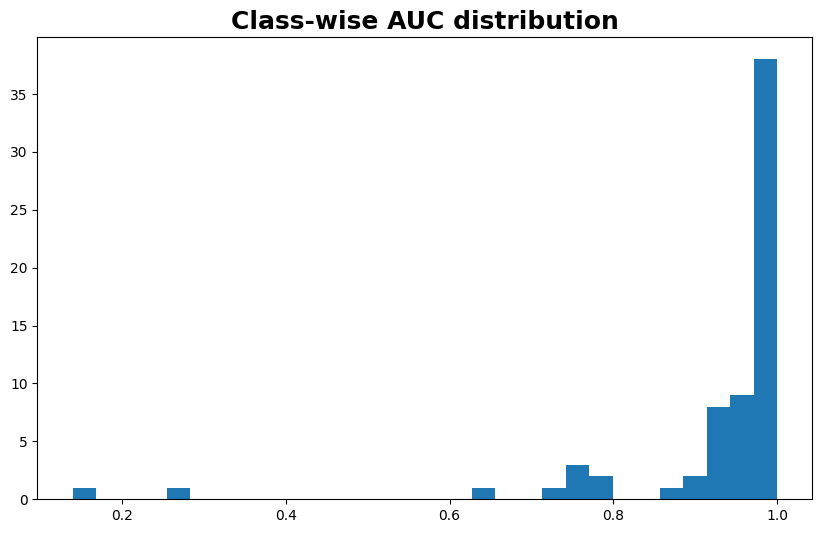

In [38]:
if not IS_TEST_ENV:
    auc_list = []
    for i, col in enumerate(species_cols):
        y_true = gt_array[:, i]
        y_pred = pred[:, i]
    
        # NO positive: skip
        if y_true.sum() == 0:
            continue
    
        auc = roc_auc_score(y_true, y_pred)
        auc_list.append({
            "species"  : col,
            "auc"      : auc,
            "pos_count": int(y_true.sum())
        })
    
    auc_df = pd.DataFrame(auc_list)

    display(auc_df.sort_values("auc").head(10))
    display(auc_df.sort_values("auc", ascending=False).head(10))
    display(auc_df.sort_values("pos_count").head(10))

    plt.figure(figsize=(10, 6))
    plt.hist(auc_df["auc"], bins=30)
    plt.title("Class-wise AUC distribution", size=18, fontweight="bold")
    plt.show()

In [39]:
#Total time: 1.01 min : test time: 14minutes
#Total time: 1.78 min : test time: 19minutes
